In [1]:
from enum import Enum
from typing import List, Dict, Any
from pydantic import BaseModel

class MOVE(str, Enum):
    up = 'up'
    left = 'left'
    right = 'right'
    down = 'down'

class Point(BaseModel):
    x: int
    y: int

class Snake(BaseModel):
    id: str
    name: str
    health: int
    body: List[Point]
    head: Point
    length: int

class Board(BaseModel):
    height: int
    width: int
    food: List[Point]
    hazards: List[Point]
    snakes: List[Snake]

class MoveRequestBody(BaseModel):
    game: Dict[str, Any]
    turn: int
    board: Board
    you: Snake

class MoveResponseBody(BaseModel):
    move: MOVE
    shout: str


In [2]:
class Neighbor:
    def __init__(self, move: MOVE, x: int, y: int):
        self.move = move
        self.x = x
        self.y = y

    def to_point(self) -> Point:
        return Point(x=self.x, y=self.y)


def get_neighbors(point: Point, board: Board) -> List[Neighbor]:
    neighbors: List[Neighbor] = []
    if point.x + 1 < board.width:
        neighbors.append(Neighbor(MOVE.right, point.x + 1, point.y))
    if point.x - 1 >= 0:
        neighbors.append(Neighbor(MOVE.left, point.x - 1, point.y))
    if point.y + 1 < board.height:
        neighbors.append(Neighbor(MOVE.up, point.x, point.y + 1))
    if point.y - 1 >= 0:
        neighbors.append(Neighbor(MOVE.down, point.x, point.y - 1))
    return neighbors

In [3]:
def is_point_in_bounds(point: Point, board: Board) -> bool:
    return 0 <= point.x < board.width and 0 <= point.y < board.height

In [4]:
def is_point_invalid(point: Point, board: Board) -> bool:
    if not is_point_in_bounds(point, board):
        return True
    busy = [p for snake in board.snakes for p in snake.body]
    busy.extend(board.hazards)
    return any(p.x == point.x and p.y == point.y for p in busy)

In [5]:
from collections import deque

def get_free_space(start: Point, board: Board) -> int:
    queue = deque([start])
    visited = {f"{start.x},{start.y}"}
    free_space = 0
    while queue:
        point = queue.popleft()
        free_space += 1
        for neighbor in get_neighbors(point, board):
            key = f"{neighbor.x},{neighbor.y}"
            pt = neighbor.to_point()
            if key not in visited and not is_point_invalid(pt, board):
                visited.add(key)
                queue.append(pt)
    return free_space

In [6]:
def get_food_heuristic(start: Point, board: Board) -> Point:
    distances = [abs(f.x - start.x) + abs(f.y - start.y) for f in board.food]
    idx = distances.index(min(distances))
    return board.food[idx]

In [7]:
def pathfinding(start: Point, end: Point) -> MOVE:
    if start.x == end.x and start.y == end.y:
        return MOVE.down
    if start.x < end.x:
        return MOVE.right
    if start.x > end.x:
        return MOVE.left
    if start.y < end.y:
        return MOVE.up
    if start.y > end.y:
        return MOVE.down
    return MOVE.down

In [8]:
def will_lose_head_to_head(you: Snake, board: Board, move: Point) -> bool:
    next_neighbors = [n for n in get_neighbors(move, board)
                      if not any(b.x == n.x and b.y == n.y for b in you.body)]
    for neighbor in next_neighbors:
        for s in board.snakes:
            if s.head.x == neighbor.x and s.head.y == neighbor.y and s.length >= you.length:
                return True
    return False

In [9]:
def get_best_move(you: Snake, board: Board) -> MOVE:
    start = you.head
    best_move = MOVE.up
    max_space = -1
    for move in MOVE:
        next_pt = Point(x=start.x, y=start.y)
        if move == MOVE.right:
            next_pt.x += 1
        elif move == MOVE.left:
            next_pt.x -= 1
        elif move == MOVE.up:
            next_pt.y += 1
        elif move == MOVE.down:
            next_pt.y -= 1
        if not is_point_invalid(next_pt, board) and not will_lose_head_to_head(you, board, next_pt):
            space = get_free_space(next_pt, board)
            if space > max_space:
                max_space = space
                best_move = move
    return best_move

In [10]:
def move_handler(req: MoveRequestBody) -> MoveResponseBody:
    board = req.board
    you = req.you
    move = MOVE.up
    if you.health <= 98:
        closest = get_food_heuristic(you.head, board)
        next_move = pathfinding(you.head, closest)
        neighbors = get_neighbors(you.head, board)
        if neighbors:
            for n in neighbors:
                pt = n.to_point()
                if n.move == next_move and not is_point_invalid(pt, board) and not will_lose_head_to_head(you, board, pt):
                    move = next_move
                    break
                else:
                    move = get_best_move(you, board)
        else:
            move = get_best_move(you, board)
    else:
        move = get_best_move(you, board)
    return MoveResponseBody(move=move, shout=f"I'm moving {move}!")

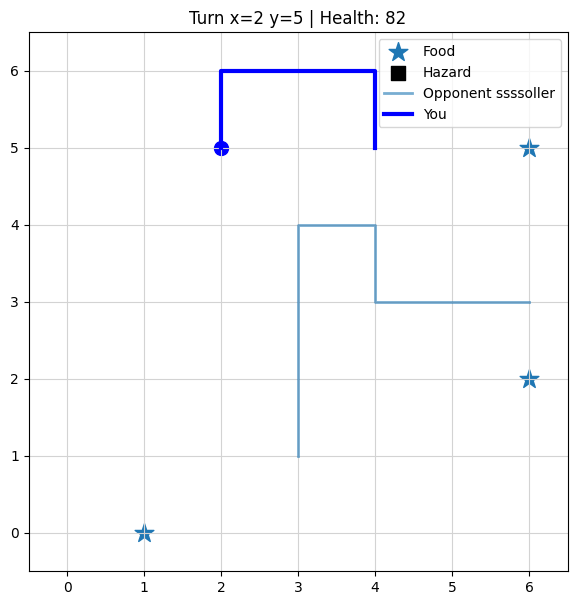

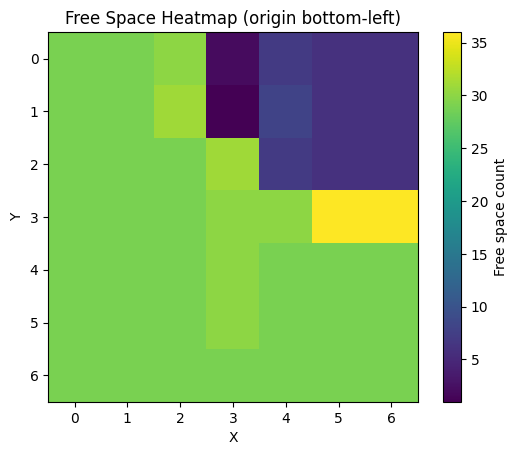

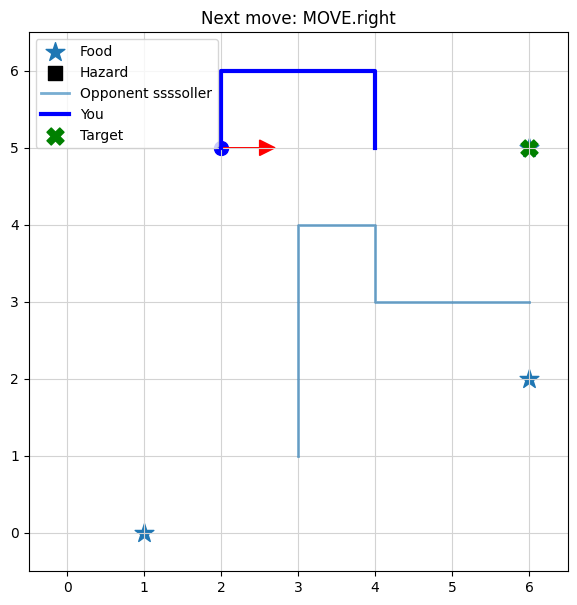

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import json

def plot_board(board: Board, you: Snake, show_grid: bool = True):
    """Desenha o tabuleiro, comida, perigos e cobras."""
    fig, ax = plt.subplots(figsize=(board.width, board.height))
    ax.set_xlim(-0.5, board.width - 0.5)
    ax.set_ylim(-0.5, board.height - 0.5)

    if show_grid:
        ax.set_xticks(range(board.width))
        ax.set_yticks(range(board.height))
        ax.grid(True, color='lightgray')

    # Desenha comida
    fx = [p.x for p in board.food]
    fy = [p.y for p in board.food]
    ax.scatter(fx, fy, marker='*', s=200, label='Food')

    # Desenha hazards
    hx = [p.x for p in board.hazards]
    hy = [p.y for p in board.hazards]
    ax.scatter(hx, hy, marker='s', s=100, c='black', label='Hazard')

    # Desenha cobras
    for snake in board.snakes:
        bx = [p.x for p in snake.body]
        by = [p.y for p in snake.body]
        if snake.id == you.id:
            ax.plot(bx, by, linewidth=3, label='You', c='blue')
            ax.scatter([you.head.x], [you.head.y], c='blue', s=100)
        else:
            ax.plot(bx, by, linewidth=2, label=f'Opponent {snake.name}', alpha=0.6)

    ax.legend(loc='upper right')
    ax.set_aspect('equal')
    plt.title(f'Turn {you.head} | Health: {you.health}')
    return fig, ax

def plot_free_space_heatmap(board: Board, you: Snake):
    """Mostra um heatmap do espaço livre a partir de cada célula do tabuleiro."""
    Z = np.zeros((board.height, board.width), dtype=int)

    for y in range(board.height):
        for x in range(board.width):
            Z[board.height - 1 - y, x] = get_free_space(Point(x=x, y=y), board)

    fig, ax = plt.subplots()
    c = ax.imshow(Z, cmap='viridis', interpolation='nearest')
    fig.colorbar(c, ax=ax, label='Free space count')
    ax.set_title('Free Space Heatmap (origin bottom-left)')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    return fig, ax

def plot_path(start: Point, end: Point, board: Board, you: Snake):
    """Plota o melhor caminho até a comida (heurística simples)."""
    # Obtém direção inicial
    first_move = pathfinding(start, end)
    # Vamos desenhar apenas a seta do primeiro passo
    dx, dy = 0, 0
    if first_move == MOVE.up:
        dy = 1
    elif first_move == MOVE.down:
        dy = -1
    elif first_move == MOVE.left:
        dx = -1
    elif first_move == MOVE.right:
        dx = 1

    fig, ax = plot_board(board, you)
    ax.arrow(start.x, start.y, dx*0.5, dy*0.5, head_width=0.2, head_length=0.2, fc='red', ec='red')
    ax.scatter([end.x], [end.y], marker='X', s=150, c='green', label='Target')
    ax.legend()
    ax.set_title(f'Next move: {first_move}')
    return fig, ax

# Exemplo de uso:
if __name__ == '__main__':
    # Supondo que você receba um MoveRequestBody `req`

    # Carregar um JSON de teste (você pode trocar por um real)
    with open('sample_request.json') as f:
        req = MoveRequestBody.model_validate_json(f.read())

    fig1, ax1 = plot_board(req.board, req.you)
    fig2, ax2 = plot_free_space_heatmap(req.board, req.you)
    fig3, ax3 = plot_path(req.you.head, req.board.food[0], req.board, req.you)

    plt.show()